In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import ast

# Load Dataset
df = pd.read_csv("imdb_data (1).csv")

# -------------------------------
# Data Cleaning
# -------------------------------
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

# Create Metrics
df['profit'] = df['revenue'] - df['budget']
df['roi'] = df['profit'] / df['budget']

# -------------------------------
# Helper Functions
# -------------------------------
def get_names(data, key='name'):
    if isinstance(data, str):
        try:
            return [i[key] for i in ast.literal_eval(data)]
        except (ValueError, SyntaxError):
            return []
    return []

# Extract Columns
df['actors'] = df['cast'].apply(lambda x: get_names(x))
df['producers'] = df['crew'].apply(lambda x: [i['name'] for i in ast.literal_eval(x) if i['job']=='Producer'] if isinstance(x, str) else [])
df['directors'] = df['crew'].apply(lambda x: [i['name'] for i in ast.literal_eval(x) if i['job']=='Director'] if isinstance(x, str) else [])

# -------------------------------
# Q1: Highest Profit Movie
# -------------------------------
top_movie = df.sort_values(by='profit', ascending=False).iloc[0]

print("\nQ1: Highest Profit Movie\n")
print("Movie:", top_movie['title'])
print("Profit:", top_movie['profit'])
print("Producer(s):", top_movie['producers'])
print("Director(s):", top_movie['directors'])
print("Actors:", top_movie['actors'])

# -------------------------------
# Q2: Language with Highest ROI
# -------------------------------
lang_roi = df.groupby('original_language')['roi'].mean().sort_values(ascending=False)

print("\nQ2: Language with Highest ROI\n")
print(lang_roi.head(1))

# -------------------------------
# Q3: Unique Genres
# -------------------------------
df['genres_list'] = df['genres'].apply(get_names)

all_genres = set([g for sublist in df['genres_list'] for g in sublist])

print("\nQ3: Unique Genres\n")
print(all_genres)

# -------------------------------
# Q4: Top 3 Producers by ROI
# -------------------------------
df_exploded = df.explode('producers')

producer_roi = (
    df_exploded.groupby('producers')['roi']
    .mean()
    .sort_values(ascending=False)
    .head(3)
)

print("\nQ4: Top 3 Producers by ROI\n")
print(producer_roi)

# -------------------------------
# Q5: Most Frequent Actor Analysis
# -------------------------------
df_exploded_actors = df.explode('actors')

actor_count = df_exploded_actors['actors'].value_counts()
top_actor = actor_count.idxmax()

print("\nQ5: Most Frequent Actor\n")
print("Actor:", top_actor)
print("Number of Movies:", actor_count.max())

actor_movies = df_exploded_actors[df_exploded_actors['actors'] == top_actor]

print("\nMovies of this actor:\n")
print(actor_movies[['title','profit']].head())

# -------------------------------
# Q6: Directors & Preferred Actors
# -------------------------------
df_dir_actor = df.explode('directors').explode('actors')

top_directors = df_dir_actor['directors'].value_counts().head(3).index

print("\nQ6: Top Directors and their Preferred Actors\n")

for director in top_directors:
    actors = (
        df_dir_actor[df_dir_actor['directors'] == director]['actors']
        .value_counts()
        .head(3)
    )
    print(f"\nDirector: {director}")
    print(actors)
    import matplotlib.pyplot as plt
import seaborn as sns








Q1: Highest Profit Movie

Movie: Furious 7
Profit: 1316249360
Producer(s): ['Vin Diesel', 'Neal H. Moritz', 'Michael Fottrell', 'Brandon Birtell']
Director(s): ['James Wan']
Actors: ['Vin Diesel', 'Paul Walker', 'Dwayne Johnson', 'Michelle Rodriguez', 'Tyrese Gibson', 'Ludacris', 'Jordana Brewster', 'Djimon Hounsou', 'Tony Jaa', 'Ronda Rousey', 'Nathalie Emmanuel', 'Kurt Russell', 'Jason Statham', 'Sung Kang', 'Gal Gadot', 'Lucas Black', 'Elsa Pataky', 'Noel Gugliemi', 'John Brotherton', 'Luke Evans', 'Ali Fazal', 'Miller Kimsey', 'Charlie Kimsey', 'Eden Estrella', 'Gentry White', 'Iggy Azalea', 'Jon Lee Brody', 'Levy Tran', 'Anna Colwell', 'Viktor Hernandez', 'Steve Coulter', 'Robert Pralgo', 'Antwan Mills', 'J.J. Phillips', 'Jorge Ferragut', 'Sara Sohn', 'Benjamin Blankenship', 'D.J. Hapa', 'T-Pain', 'Brian Mahoney', 'Brittney Alger', 'Romeo Santos', 'Jocelin Donahue', 'Stephanie Langston', 'Jorge-Luis Pallo', 'Tego Calder√≥n', 'Nathalie Kelley', 'Shad Moss', 'Don Omar', 'Klement Ti

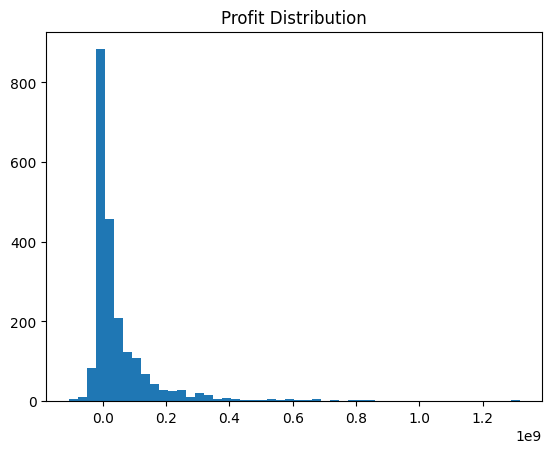

In [10]:
plt.hist(df['profit'], bins=50)
plt.title("Profit Distribution")
plt.show()

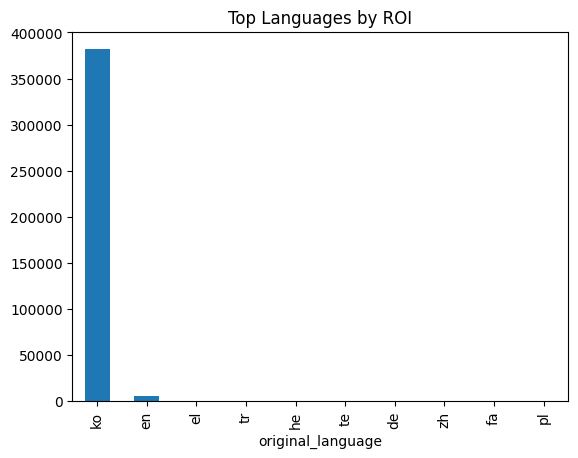

In [11]:
lang_roi.head(10).plot(kind='bar')
plt.title("Top Languages by ROI")
plt.show()

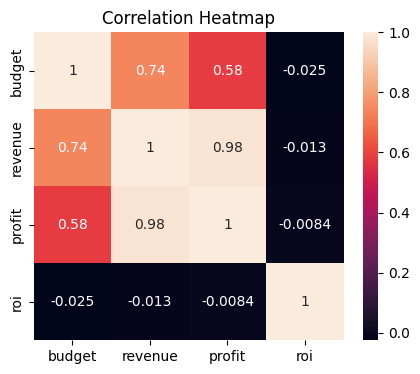

In [12]:
plt.figure(figsize=(5,4))
sns.heatmap(df[['budget','revenue','profit','roi']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

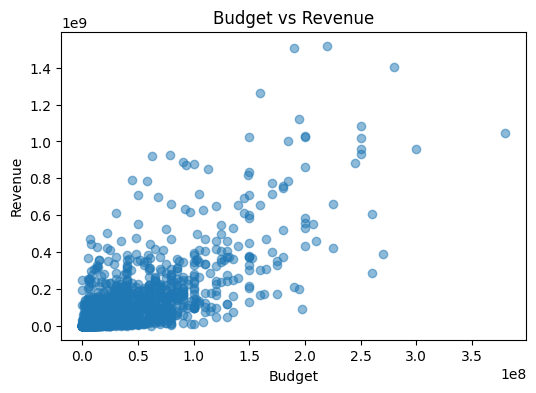

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(df['budget'], df['revenue'], alpha=0.5)
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()